# 🛡️ Network Intrusion Detection with Machine Learning (NSL-KDD)

**Author: Piyush Kumar** — Cybersecurity Specialist | Penetration Tester | SOC Analyst
Ranked **Top #145 globally on TryHackMe** · Author of 3 cybersecurity books

📧 mr.piyush295@gmail.com · 🔗 [linkedin.com/in/hackerpiyush295](https://linkedin.com/in/hackerpiyush295)

---

## Overview

Network Intrusion Detection Systems (IDS) are a core part of any Security Operations
Center (SOC). In this notebook I build machine-learning models on the **NSL-KDD**
benchmark dataset to automatically classify network connections as **normal** or
**attack**, and further identify the **type of attack** (DoS, Probe, R2L, U2R).

**What you'll find here:**
1. Data loading & understanding the 41 network features
2. Exploratory Data Analysis (EDA) with visualizations
3. Preprocessing (encoding + scaling)
4. **Binary** detection model — normal vs attack
5. **Multi-class** model — attack category classification
6. Model evaluation, confusion matrices & feature importance
7. SOC-oriented takeaways

> 💡 This project reflects a defensive, blue-team use case: detecting intrusions in
> network traffic — exactly the kind of automation that augments a SOC analyst's workflow.


## 1. Setup & Imports

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
pd.set_option("display.max_columns", 100)
print("Libraries loaded.")

Libraries loaded.


## DATA LOADING

The local `nsl-kdd/` directory contains the reduced and full training files plus `KDDTest+.txt` and the harder `KDDTest-21.txt` split.


In [34]:
COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty",
]

# Keep the data root in one variable so the same cell works locally and in Colab.
DATA_DIR = "nsl-kdd"
def load_nsl_kdd(filename):
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing NSL-KDD file: {path}")
    return pd.read_csv(path, names=COLUMNS).drop(columns=["difficulty"])

train_full = load_nsl_kdd("KDDTrain+.txt")
train = load_nsl_kdd("KDDTrain+_20Percent.txt")
test = load_nsl_kdd("KDDTest+.txt")
test_harder = load_nsl_kdd("KDDTest-21.txt")

print(f"Reduced train shape: {train.shape}")
print(f"Full train shape:    {train_full.shape}")
print(f"KDDTest+ shape:      {test.shape}")
print(f"KDDTest-21 shape:    {test_harder.shape}")
train.head()

Reduced train shape: (25192, 42)
Full train shape:    (125973, 42)
KDDTest+ shape:      (22544, 42)
KDDTest-21 shape:    (11850, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## 3. Building the Target Labels

Each record's `label` is either `normal` or a specific attack name. We create:
- **binary target**: `normal` (0) vs `attack` (1)
- **category target**: mapping every attack to one of four classic families:
  - **DoS** – Denial of Service (e.g. neptune, smurf)
  - **Probe** – surveillance / scanning (e.g. nmap, satan)
  - **R2L** – Remote to Local unauthorized access (e.g. guess_passwd)
  - **U2R** – User to Root privilege escalation (e.g. buffer_overflow)

In [35]:
ATTACK_CATEGORY = {
    "neptune":"DoS","back":"DoS","land":"DoS","pod":"DoS","smurf":"DoS",
    "teardrop":"DoS","mailbomb":"DoS","apache2":"DoS","processtable":"DoS",
    "udpstorm":"DoS","worm":"DoS",
    "ipsweep":"Probe","nmap":"Probe","portsweep":"Probe","satan":"Probe",
    "mscan":"Probe","saint":"Probe",
    "ftp_write":"R2L","guess_passwd":"R2L","imap":"R2L","multihop":"R2L",
    "phf":"R2L","spy":"R2L","warezclient":"R2L","warezmaster":"R2L",
    "sendmail":"R2L","named":"R2L","snmpgetattack":"R2L","snmpguess":"R2L",
    "xlock":"R2L","xsnoop":"R2L","httptunnel":"R2L",
    "buffer_overflow":"U2R","loadmodule":"U2R","perl":"U2R","rootkit":"U2R",
    "ps":"U2R","sqlattack":"U2R","xterm":"U2R",
}
def categorize(lbl):
    return "normal" if lbl == "normal" else ATTACK_CATEGORY.get(lbl, "other_attack")

# Apply the same mapping to every split; unknown attack names remain explicit.
for df in (train_full, train, test, test_harder):
    df["binary"] = (df["label"] != "normal").astype(int)
    df["category"] = df["label"].map(categorize)

for name, df in (("train (20%)", train), ("train (full)", train_full),
                 ("KDDTest+", test), ("KDDTest-21", test_harder)):
    print(f"\n{name}: shape={df.shape}")
    print(df["category"].value_counts().reindex(["normal", "DoS", "Probe", "R2L", "U2R", "other_attack"], fill_value=0))
    print(f"Unseen raw attack names: {sorted(set(df['label']) - set(train['label']))}")


train (20%): shape=(25192, 44)
category
normal          13449
DoS              9234
Probe            2289
R2L               209
U2R                11
other_attack        0
Name: count, dtype: int64
Unseen raw attack names: []

train (full): shape=(125973, 44)
category
normal          67343
DoS             45927
Probe           11656
R2L               995
U2R                52
other_attack        0
Name: count, dtype: int64
Unseen raw attack names: ['perl']

KDDTest+: shape=(22544, 44)
category
normal          9711
DoS             7460
Probe           2421
R2L             2885
U2R               67
other_attack       0
Name: count, dtype: int64
Unseen raw attack names: ['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'perl', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']

KDDTest-21: shape=(11850, 44)
category
normal          2152
DoS             4344
Probe           2402
R2L             2885
U

## 4. Exploratory Data Analysis

### 4.1 Normal vs Attack balance

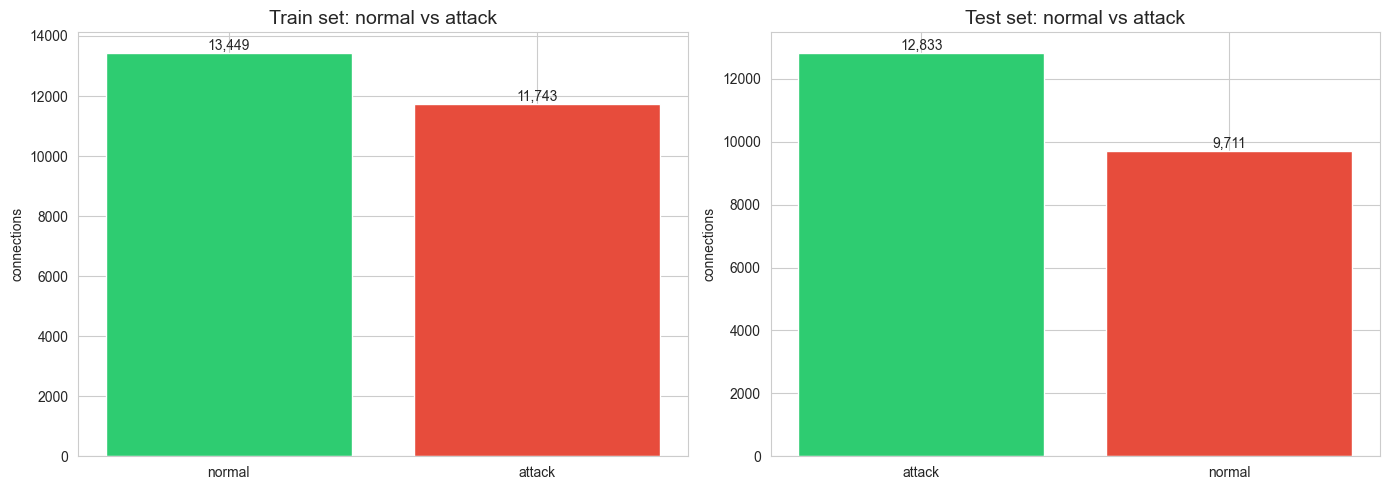

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, (df, name) in zip(ax, [(train,"Train"), (test,"Test")]):
    counts = df["binary"].map({0:"normal",1:"attack"}).value_counts()
    a.bar(counts.index, counts.values, color=["#2ecc71","#e74c3c"])
    a.set_title(f"{name} set: normal vs attack")
    a.set_ylabel("connections")
    for i,v in enumerate(counts.values):
        a.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

### 4.2 Attack categories

C:\Users\raghu\AppData\Local\Temp\ipykernel_3544\1500571973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x="category", order=order, palette="rocket")


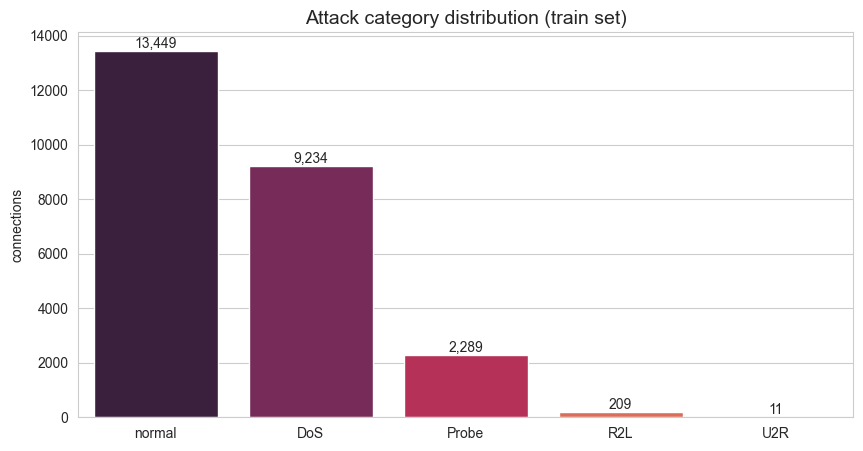

In [37]:
plt.figure(figsize=(10,5))
order = train["category"].value_counts().index
sns.countplot(data=train, x="category", order=order, palette="rocket")
plt.title("Attack category distribution (train set)")
plt.ylabel("connections"); plt.xlabel("")
for i, c in enumerate(order):
    n = (train["category"]==c).sum()
    plt.text(i, n, f"{n:,}", ha="center", va="bottom")
plt.show()

### 4.3 Protocol usage: normal vs attack

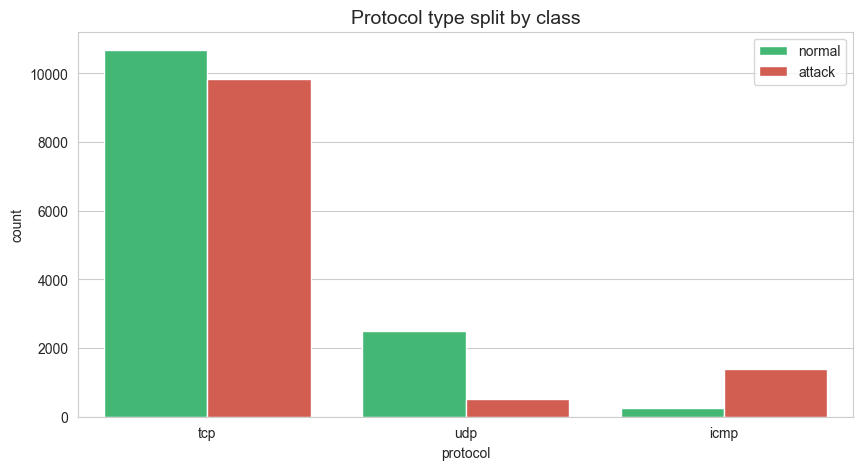

In [38]:
plt.figure(figsize=(10,5))
sns.countplot(data=train, x="protocol_type",
              hue=train["binary"].map({0:"normal",1:"attack"}),
              palette={"normal":"#2ecc71","attack":"#e74c3c"})
plt.title("Protocol type split by class"); plt.xlabel("protocol"); plt.legend(title="")
plt.show()

### 4.4 Feature correlation heatmap (numeric)

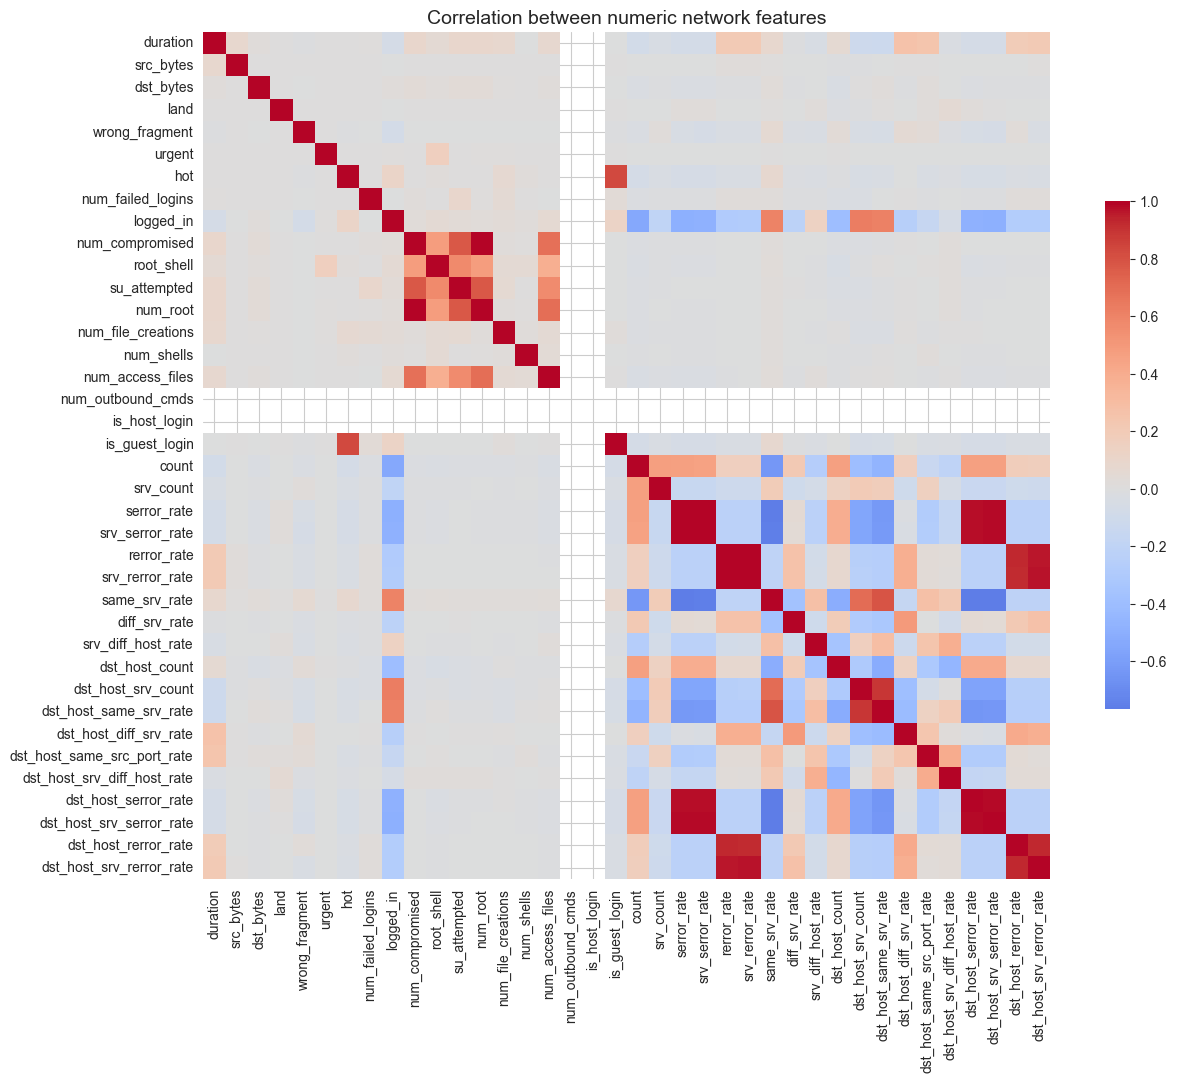

In [39]:
num = train.select_dtypes(include=[np.number]).drop(columns=["binary"])
corr = num.corr()
plt.figure(figsize=(14,11))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink":0.6})
plt.title("Correlation between numeric network features")
plt.show()

## 5. Preprocessing

We label-encode the three categorical columns (`protocol_type`, `service`, `flag`)
and standard-scale all features. Encoders are fit on the combined train+test
category space so unseen values in the test set don't break inference.

In [40]:
from sklearn.preprocessing import OrdinalEncoder

CATEGORICAL = ["protocol_type", "service", "flag"]
# Fit encoders on training rows only; unknown test categories get a reserved code.
encoders = {}
for col in CATEGORICAL:
    encoders[col] = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    train[[col]] = encoders[col].fit_transform(train[[col]])
    test[[col]] = encoders[col].transform(test[[col]])
    test_harder[[col]] = encoders[col].transform(test_harder[[col]])

feature_cols = [c for c in train.columns if c not in ("label", "binary", "category")]
scaler = StandardScaler()
X_train = scaler.fit_transform(train[feature_cols])
X_test = scaler.transform(test[feature_cols])
X_test_harder = scaler.transform(test_harder[feature_cols])
print(f"Feature matrix: {X_train.shape[1]} features")

Feature matrix: 41 features


## 6. Binary Detection Model — Normal vs Attack

We use a **Histogram-based Gradient Boosting** classifier, which handles the mix of
scaled numeric features well and trains fast.

In [41]:
bin_model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                           random_state=42)
bin_model.fit(X_train, train["binary"])
bpred = bin_model.predict(X_test)
bacc  = accuracy_score(test["binary"], bpred)
print(f"BINARY TEST ACCURACY: {bacc:.4f}  ({bacc:.2%})\n")
print(classification_report(test["binary"], bpred,
      target_names=["normal","attack"], digits=4))

BINARY TEST ACCURACY: 0.7883  (78.83%)

              precision    recall  f1-score   support

      normal     0.6774    0.9710    0.7981      9711
      attack     0.9673    0.6501    0.7776     12833

    accuracy                         0.7883     22544
   macro avg     0.8224    0.8105    0.7878     22544
weighted avg     0.8424    0.7883    0.7864     22544



### 6.1 Confusion matrix

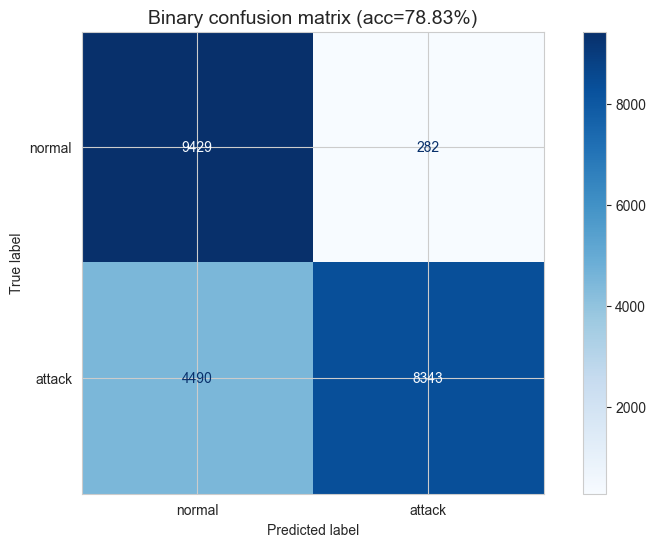

In [42]:
cm = confusion_matrix(test["binary"], bpred)
disp = ConfusionMatrixDisplay(cm, display_labels=["normal","attack"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Binary confusion matrix (acc={bacc:.2%})"); plt.show()

## 7. Multi-class Model — Attack Category

Now we predict the *family* of the connection: normal / DoS / Probe / R2L / U2R.
This is a harder problem, and the NSL-KDD test set deliberately contains attack
variants not seen in training — which is exactly why it is a respected benchmark.

In [43]:
cat_model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                           random_state=42)
cat_model.fit(X_train, train["category"])
cpred = cat_model.predict(X_test)
cacc  = accuracy_score(test["category"], cpred)
print(f"MULTI-CLASS TEST ACCURACY: {cacc:.4f}  ({cacc:.2%})\n")
print(classification_report(test["category"], cpred, digits=4, zero_division=0))

MULTI-CLASS TEST ACCURACY: 0.7382  (73.82%)

              precision    recall  f1-score   support

         DoS     0.9568    0.7595    0.8468      7460
       Probe     0.7760    0.6068    0.6810      2421
         R2L     0.8922    0.0315    0.0609      2885
         U2R     0.2456    0.2090    0.2258        67
      normal     0.6453    0.9682    0.7744      9711

    accuracy                         0.7382     22544
   macro avg     0.7032    0.5150    0.5178     22544
weighted avg     0.7928    0.7382    0.6954     22544



### 7.1 Multi-class confusion matrix

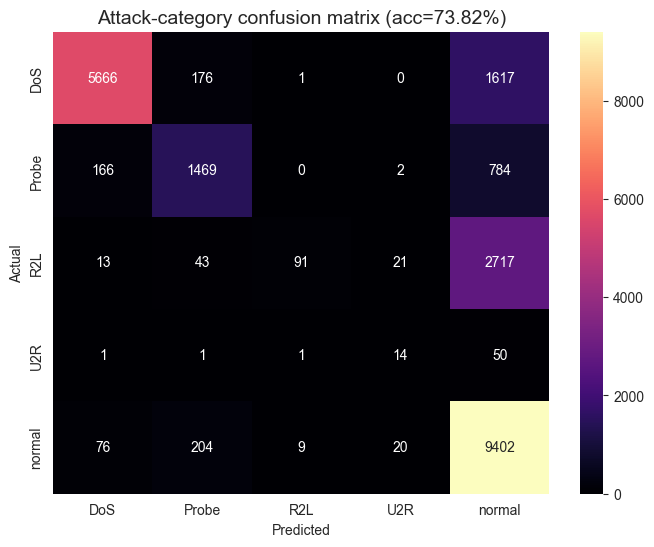

In [44]:
labels = sorted(test["category"].unique())
cm = confusion_matrix(test["category"], cpred, labels=labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Attack-category confusion matrix (acc={cacc:.2%})"); plt.show()

## 8. Which features matter most?

Using a Random Forest as an interpretable reference model, we look at the features
that carry the most signal for intrusion detection.

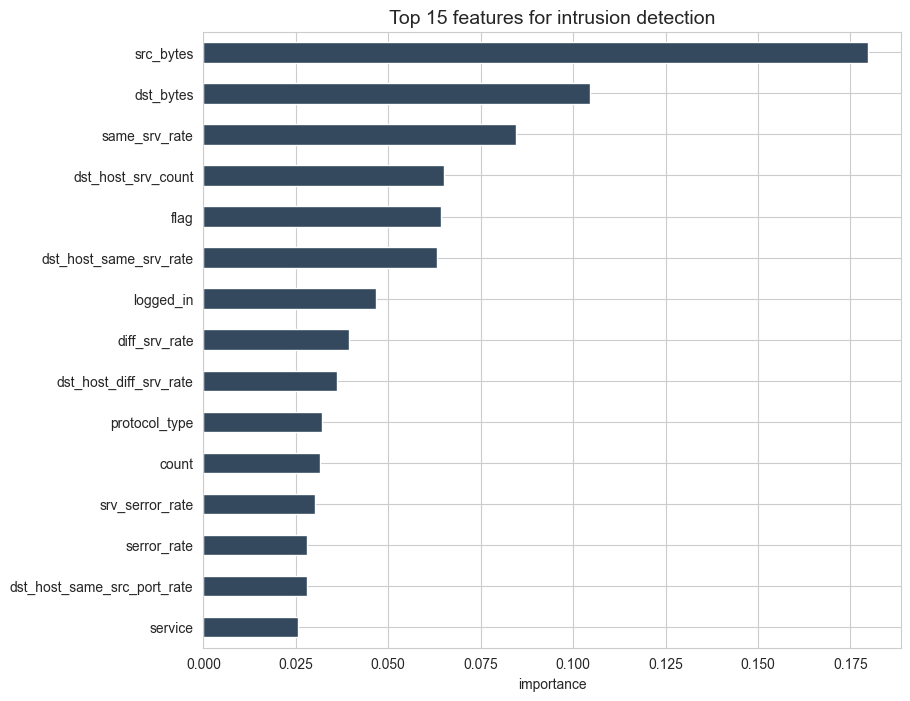

In [45]:
rf = RandomForestClassifier(n_estimators=120, n_jobs=-1, random_state=42)
rf.fit(X_train, train["binary"])
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(9,8))
imp.tail(15).plot(kind="barh", color="#34495e")
plt.title("Top 15 features for intrusion detection")
plt.xlabel("importance"); plt.show()

## 9. Conclusions & SOC Takeaways

Use the measured tables and plots above for the conclusions from this run. No fixed accuracy claims are recorded here: the reduced training split, both test splits, and each model comparison report their metrics at execution time.

The per-class results should guide SOC prioritization, especially for rare R2L and U2R records, while the normalized confusion matrices show where the selected model confuses attack families.


## DATA LOADING

The cells above load the reduced training set for all fitting and both requested test sets. Raw attack names that do not occur in reduced training are retained and mapped to \"other_attack\" rather than being silently dropped.

## Optional dependencies

In [46]:
%pip install -q imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
%pip install -q xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
%pip install -q lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
%pip install -q shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## CLASS IMBALANCE

These experiments use Random Forest because it supports class weights directly. SMOTE is fit only on the reduced training matrix; neither test matrix is resampled.

In [50]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, recall_score

imbalance_models = {
    "baseline": RandomForestClassifier(n_estimators=120, n_jobs=-1, random_state=42),
    "class_weight=balanced": RandomForestClassifier(n_estimators=120, class_weight="balanced", n_jobs=-1, random_state=42),
}
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, train["category"])
imbalance_models["SMOTE"] = RandomForestClassifier(n_estimators=120, n_jobs=-1, random_state=42)

imbalance_rows = []
for name, model in imbalance_models.items():
    X_fit, y_fit = (X_train_smote, y_train_smote) if name == "SMOTE" else (X_train, train["category"])
    model.fit(X_fit, y_fit)
    pred = model.predict(X_test)
    for cls in ["R2L", "U2R"]:
        imbalance_rows.append({"method": name, "class": cls,
                               "recall": recall_score(test["category"], pred, labels=[cls], average=None, zero_division=0)[0],
                               "f1": f1_score(test["category"], pred, labels=[cls], average=None, zero_division=0)[0]})
imbalance_results = pd.DataFrame(imbalance_rows)
print(imbalance_results.to_string(index=False))

               method class   recall       f1
             baseline   R2L 0.041248 0.079201
             baseline   U2R 0.014925 0.029412
class_weight=balanced   R2L 0.001040 0.002078
class_weight=balanced   U2R 0.029851 0.057971
                SMOTE   R2L 0.048180 0.091901
                SMOTE   U2R 0.059701 0.106667


## MODEL COMPARISON

All models use the same reduced-training split and the same train-only preprocessing. XGBoost is used as the optional boosted-tree comparison.

In [51]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_fscore_support

comparison_models = {
    "Random Forest": RandomForestClassifier(n_estimators=120, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=180, max_depth=8, learning_rate=0.1,
                              subsample=0.9, colsample_bytree=0.9, eval_metric="mlogloss",
                              tree_method="hist", random_state=42, n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, random_state=42),
}
comparison_rows = []
comparison_fitted = {}
target_encoder = LabelEncoder().fit(train["category"])
y_train_encoded = target_encoder.transform(train["category"])
def predict_categories(name, model, X_eval):
    pred = model.predict(X_eval)
    return target_encoder.inverse_transform(pred.astype(int)) if name == "XGBoost" else pred
for name, model in comparison_models.items():
    model.fit(X_train, y_train_encoded if name == "XGBoost" else train["category"])
    comparison_fitted[name] = model
    for split_name, X_eval, y_eval in (("KDDTest+", X_test, test["category"]), ("KDDTest-21", X_test_harder, test_harder["category"])):
        pred = predict_categories(name, model, X_eval)
        comparison_rows.append({
            "model": name, "test_set": split_name,
            "accuracy": accuracy_score(y_eval, pred),
            "macro_f1": f1_score(y_eval, pred, average="macro", zero_division=0),
            "weighted_f1": f1_score(y_eval, pred, average="weighted", zero_division=0),
            "R2L_recall": recall_score(y_eval, pred, labels=["R2L"], average=None, zero_division=0)[0],
            "U2R_recall": recall_score(y_eval, pred, labels=["U2R"], average=None, zero_division=0)[0],
        })
comparison_results = pd.DataFrame(comparison_rows)
print(comparison_results.round(4).to_string(index=False))
best_model_name = comparison_results.loc[comparison_results["test_set"].eq("KDDTest+")].sort_values("macro_f1", ascending=False).iloc[0]["model"]
best_model = comparison_fitted[best_model_name]
print(f"Best model by KDDTest+ macro F1: {best_model_name}")

               model   test_set  accuracy  macro_f1  weighted_f1  R2L_recall  U2R_recall
       Random Forest   KDDTest+    0.7630    0.5006       0.7198      0.0412      0.0149
       Random Forest KDDTest-21    0.5497    0.4096       0.5335      0.0412      0.0149
             XGBoost   KDDTest+    0.7666    0.5280       0.7267      0.0641      0.0746
             XGBoost KDDTest-21    0.5560    0.4371       0.5437      0.0641      0.0746
 Logistic Regression   KDDTest+    0.7491    0.5354       0.7018      0.0045      0.1642
 Logistic Regression KDDTest-21    0.5234    0.4313       0.4991      0.0045      0.1642
HistGradientBoosting   KDDTest+    0.7382    0.5178       0.6954      0.0315      0.2090
HistGradientBoosting KDDTest-21    0.5028    0.4200       0.4885      0.0315      0.2090
Best model by KDDTest+ macro F1: Logistic Regression


## PER-CLASS ANALYSIS

The plots use the selected model and report real KDDTest+ and KDDTest-21 metrics. The normalized matrices show row-wise recall, so each row sums to one when the class is present.

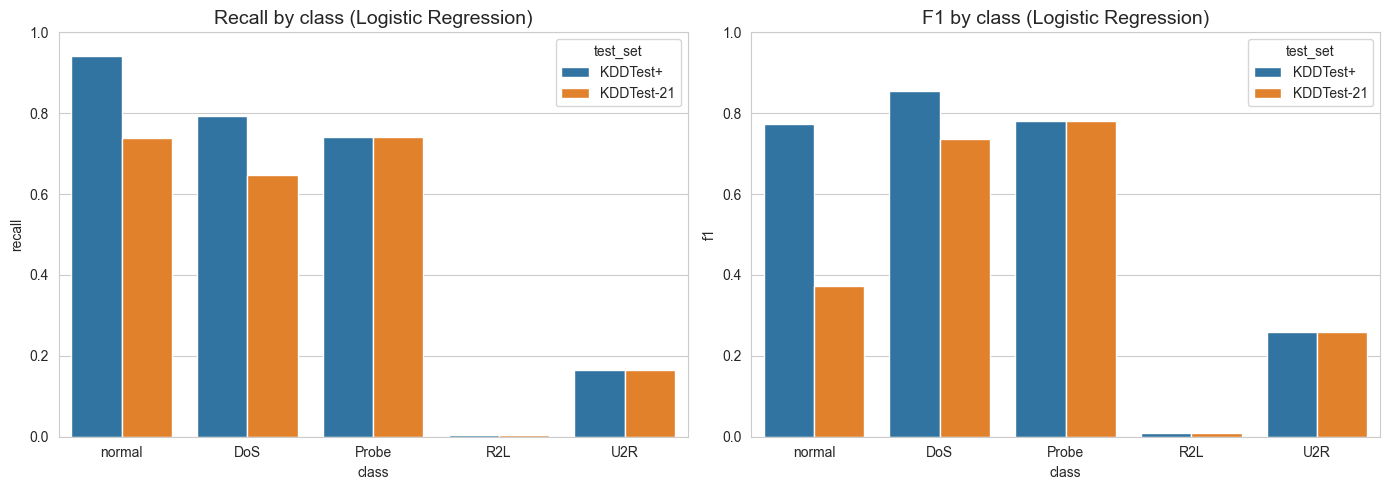

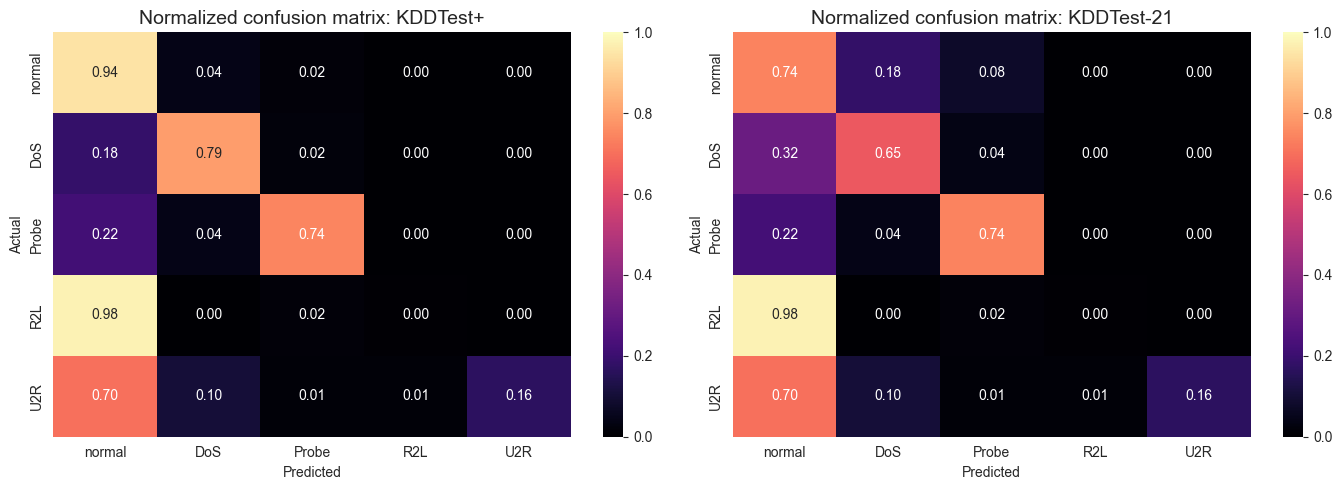

  test_set  class  recall     f1
  KDDTest+ normal  0.9414 0.7743
  KDDTest+    DoS  0.7941 0.8538
  KDDTest+  Probe  0.7423 0.7810
  KDDTest+    R2L  0.0045 0.0089
  KDDTest+    U2R  0.1642 0.2588
KDDTest-21 normal  0.7384 0.3738
KDDTest-21    DoS  0.6471 0.7351
KDDTest-21  Probe  0.7402 0.7798
KDDTest-21    R2L  0.0045 0.0090
KDDTest-21    U2R  0.1642 0.2588


In [52]:
from sklearn.metrics import classification_report

analysis_rows = []
analysis_predictions = {}
for split_name, X_eval, df in (("KDDTest+", X_test, test), ("KDDTest-21", X_test_harder, test_harder)):
    pred = predict_categories(best_model_name, best_model, X_eval)
    analysis_predictions[split_name] = pred
    report = classification_report(df["category"], pred, labels=["normal", "DoS", "Probe", "R2L", "U2R"], output_dict=True, zero_division=0)
    for cls in ["normal", "DoS", "Probe", "R2L", "U2R"]:
        analysis_rows.append({"test_set": split_name, "class": cls, "recall": report[cls]["recall"], "f1": report[cls]["f1-score"]})
per_class_results = pd.DataFrame(analysis_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=per_class_results, x="class", y="recall", hue="test_set", ax=axes[0])
axes[0].set_title(f"Recall by class ({best_model_name})"); axes[0].set_ylim(0, 1)
sns.barplot(data=per_class_results, x="class", y="f1", hue="test_set", ax=axes[1])
axes[1].set_title(f"F1 by class ({best_model_name})"); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (split_name, df) in zip(axes, (("KDDTest+", test), ("KDDTest-21", test_harder))):
    cm = confusion_matrix(df["category"], analysis_predictions[split_name], labels=["normal", "DoS", "Probe", "R2L", "U2R"], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="magma", vmin=0, vmax=1,
                xticklabels=["normal", "DoS", "Probe", "R2L", "U2R"], yticklabels=["normal", "DoS", "Probe", "R2L", "U2R"], ax=ax)
    ax.set_title(f"Normalized confusion matrix: {split_name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()
print(per_class_results.round(4).to_string(index=False))

### Interpretation

Use the printed recall and F1 values above to identify the hardest attack families. R2L and U2R are typically the most difficult because they are rare, heterogeneous, and often resemble legitimate traffic; KDDTest-21 can reduce performance further because it removes easier records and emphasizes generalization to difficult examples. The exact comparison in this run is the authoritative result.

## EXPLAINABILITY

The original Random Forest top-15 chart is retained above. The following SHAP plots explain the fitted Random Forest on a bounded sample so the notebook remains practical locally.

c:\Users\raghu\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


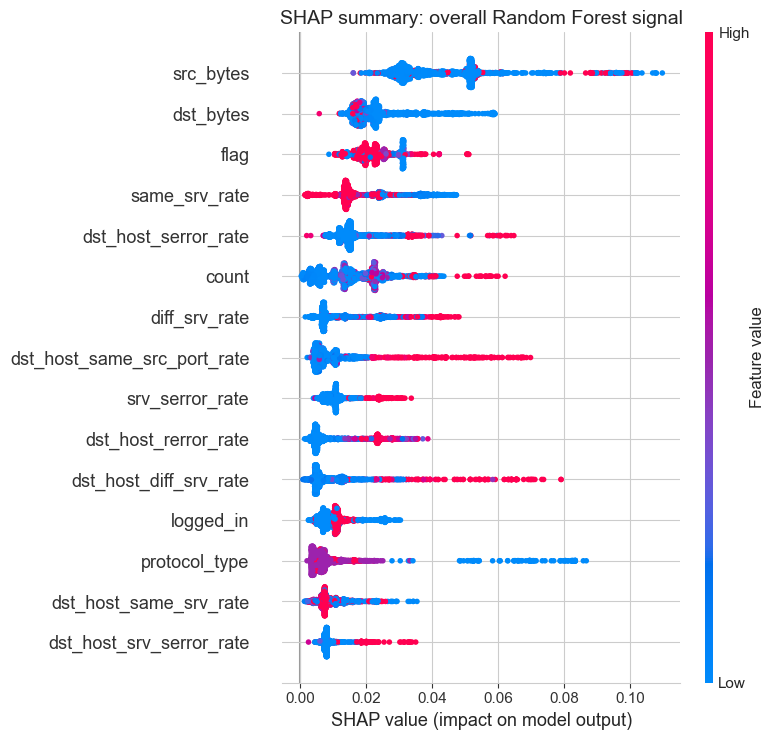

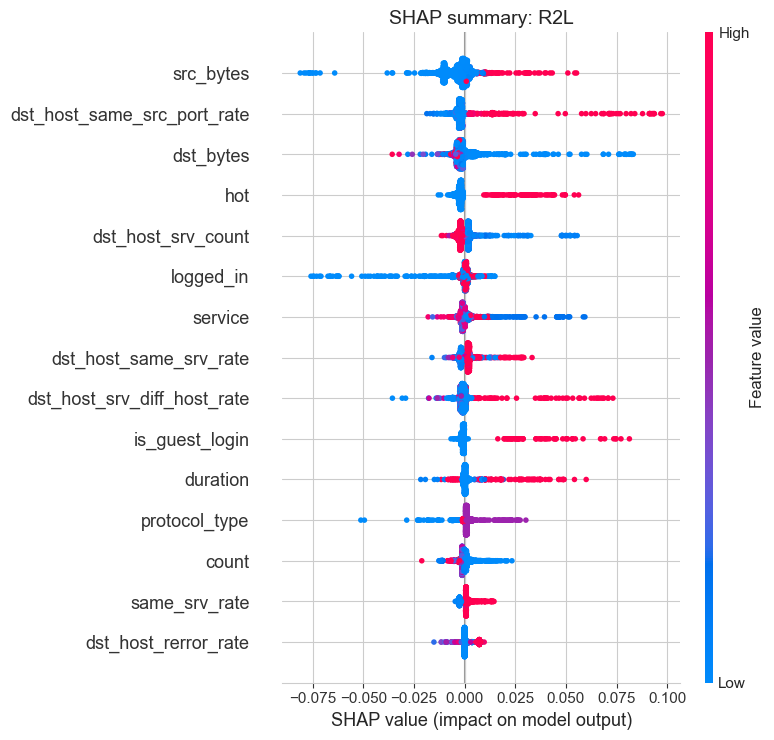

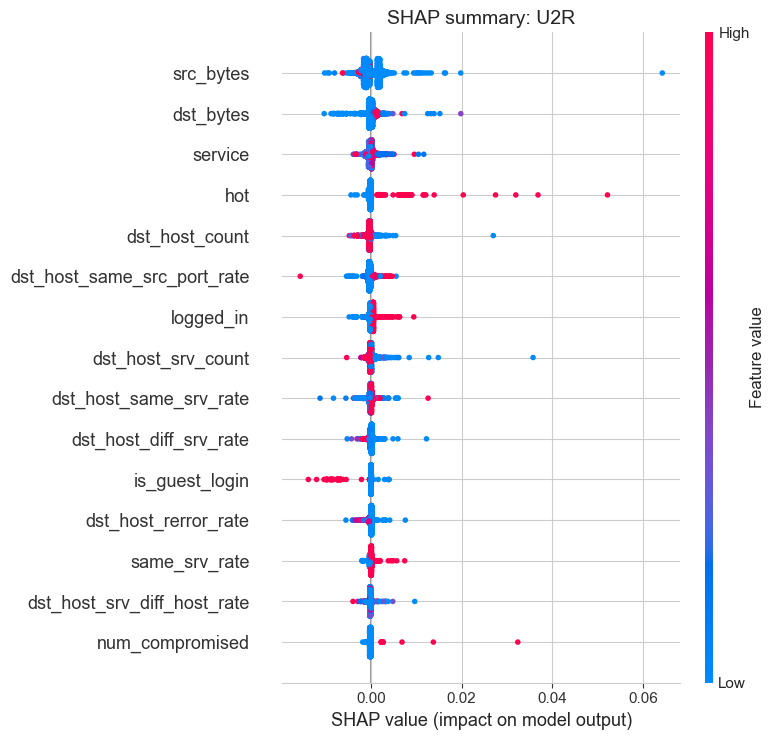

In [53]:
import shap

rf_explainer = shap.TreeExplainer(comparison_fitted["Random Forest"])
shap_sample = pd.DataFrame(X_test, columns=feature_cols).sample(min(2000, len(X_test)), random_state=42)
shap_values = rf_explainer.shap_values(shap_sample)
# TreeExplainer returns one array per class for multi-class Random Forest.
if isinstance(shap_values, list):
    overall_values = np.mean(np.abs(np.stack(shap_values)), axis=0)
else:
    overall_values = np.mean(np.abs(shap_values), axis=-1) if shap_values.ndim == 3 else shap_values
shap.summary_plot(overall_values, shap_sample, show=False, max_display=15)
plt.title("SHAP summary: overall Random Forest signal"); plt.tight_layout(); plt.show()

for cls in ["R2L", "U2R"]:
    class_idx = list(comparison_fitted["Random Forest"].classes_).index(cls)
    class_values = shap_values[class_idx] if isinstance(shap_values, list) else shap_values[:, :, class_idx]
    shap.summary_plot(class_values, shap_sample, show=False, max_display=15)
    plt.title(f"SHAP summary: {cls}"); plt.tight_layout(); plt.show()

### Top-feature interpretation

The Random Forest chart and SHAP summaries rank features by learned contribution rather than by a hand-written assumption. Features near the top should be interpreted in the context of the printed per-class results: traffic-volume and service/error-rate fields often separate DoS and Probe traffic, while the scarce R2L and U2R examples require subtler login, shell, byte-count, and service signals. SHAP direction and magnitude in the plots above are the evidence for this run.

## SAVE

In [54]:
import joblib
from pathlib import Path

Path("models").mkdir(exist_ok=True)
joblib.dump(best_model, "models/nsl_kdd_best_multiclass_model.joblib")
joblib.dump(scaler, "models/nsl_kdd_scaler.joblib")
joblib.dump(encoders, "models/nsl_kdd_feature_encoders.joblib")
joblib.dump({"classes": list(best_model.classes_), "feature_cols": feature_cols,
             "attack_category": ATTACK_CATEGORY, "target_encoder": target_encoder}, "models/nsl_kdd_metadata.joblib")
print(f"Saved {best_model_name}, scaler, encoders, and metadata under models/")

Saved Logistic Regression, scaler, encoders, and metadata under models/
